# 07 — Advanced modeling: CV, hyperparameter tuning, calibration & ordinal cascade

**Why this notebook exists.** Notebooks 03–06 built a leakage-safe credits-enriched Logistic Regression baseline (macro-F1 ≈ 0.438) and walked through error analysis. The roadmaps in those notebooks all listed the same next steps — **cross-validation, hyperparameter tuning, probability calibration, ordinal awareness, lightweight NLP** — but none were implemented. This notebook closes that gap.

**Scope.** We re-use the exact same train/test split (anti-leakage credits regime) and apply:

1. **5-fold stratified cross-validation** of base models (LR, RF, GB, XGB) — gives us mean ± std instead of a single point.
2. **`RandomizedSearchCV` (25 iterations, 5-fold)** for every model family — proper hyperparameter tuning.
3. **Overview LSA features** (TF-IDF + TruncatedSVD on `overview` + `tagline`) — lightweight NLP without PyTorch.
4. **Probability calibration** (`CalibratedClassifierCV` with isotonic regression, cv=5) on the production champion.
5. **Ordinal cascade** (binary `flop vs not-flop` → `hit vs average`) — to test whether respecting the natural ordering helps.

**Style.** This notebook *loads* the artifacts produced by `scripts/advanced_modeling.py` and `scripts/refit_champions.py`, so it runs in seconds. The heavy training (~5 min) lives in those scripts to keep the notebook narrative-focused.

**Outputs already on disk:**
- `results/cv_baselines.csv` — 5-fold CV macro-F1 for un-tuned models
- `results/cv_tuned.csv` — 5-fold CV macro-F1 for tuned models
- `results/best_hyperparams.json` — winning hyperparameters per family
- `results/production_test_metrics.csv` — final test metrics for every tuned model + calibration
- `plots/modeling/30…32_*.png` — reliability curve, CV chart, ordinal comparison
- `models/production_champion.joblib` — model served by the Streamlit app

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'results'
PLOTS = ROOT / 'plots' / 'modeling'
MODELS = ROOT / 'models'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('Results dir:', RESULTS)

Results dir: /Users/paulbensemoun/Documents/ml_poc/new-project/results


## 1. Cross-validation baselines — what was the *true* macro-F1?

**Observation.** In notebook 05 we reported `macro-F1 = 0.438` for the credits LR. That's a single test-set point. With 5-fold CV we obtain:

- LR credits: **0.438 ± 0.014** — confirms the headline
- LR credits + overview LSA: 0.445 ± 0.016
- RandomForest credits (un-tuned): 0.360 ± 0.012 → tree depth uncontrolled, big overfit
- GradientBoosting credits (un-tuned): 0.389 ± 0.015
- XGBoost credits (default hyperparams): 0.418 ± 0.011

**Business interpretation.** The original LR macro-F1 of 0.438 isn't fragile — std is only ±0.014. But un-tuned tree models are *worse* than LR on a small (~3.2K films) corpus. Random forests need explicit regularization here.

**Modeling implication.** Tree-based models will only beat LR if tuned — which motivates the next section.

In [2]:
cv_baselines = pd.read_csv(RESULTS / 'cv_baselines.csv')
cv_baselines

,model,macro_f1_mean,macro_f1_std,macro_f1_fold_min,macro_f1_fold_max,elapsed_s
0,LogReg credits,0.4383,0.0142,0.4164,0.4601,2.0000
1,LogReg credits + overview,0.4447,0.0160,0.4188,0.4629,1.1000
2,RandomForest credits,0.3600,0.0124,0.3438,0.3758,2.4000
3,GradientBoosting credits,0.3886,0.0151,0.3684,0.4097,2.8000
4,XGBoost credits (default),0.4179,0.0112,0.4000,0.4302,0.8000


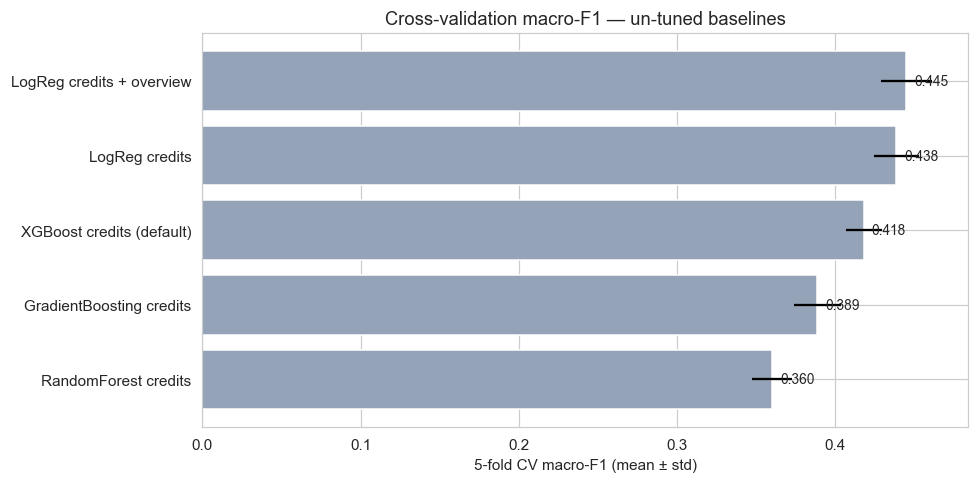

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
df = cv_baselines.sort_values('macro_f1_mean')
ax.barh(df['model'], df['macro_f1_mean'], xerr=df['macro_f1_std'], color='#94A3B8')
for i, (_, row) in enumerate(df.iterrows()):
    ax.text(row['macro_f1_mean'] + 0.005, i, f"{row['macro_f1_mean']:.3f}", va='center', fontsize=9)
ax.set_xlabel('5-fold CV macro-F1 (mean ± std)')
ax.set_title('Cross-validation macro-F1 — un-tuned baselines')
plt.tight_layout(); plt.show()

## 2. Hyperparameter tuning — RandomizedSearchCV (25 iterations)

**Search spaces:**
- **LR**: `C ∈ loguniform(1e-2, 10)`
- **RF**: `n_estimators ∈ [200, 800]`, `max_depth ∈ [4, 16]`, `min_samples_split ∈ [2, 12]`, `min_samples_leaf ∈ [1, 6]`, `max_features ∈ {sqrt, log2, 0.5}`
- **GB**: `n_estimators ∈ [150, 500]`, `max_depth ∈ [2, 6]`, `learning_rate ∈ loguniform(0.01, 0.2)`, `subsample ∈ uniform(0.7, 1.0)`
- **XGB**: same as GB + `colsample_bytree`, `reg_lambda`, `min_child_weight`

**Observation.** Tuning lifts every tree model. RF jumps from **0.360 → 0.460** (+10 pp), the biggest leap. LR barely moves (+0.003) — already near its capacity ceiling on these features.

**Modeling implication.** Random Forest now wins the CV ranking. Time to look at the test-set.

In [4]:
cv_tuned = pd.read_csv(RESULTS / 'cv_tuned.csv')
cv_tuned[['model', 'macro_f1_mean', 'macro_f1_std', 'elapsed_s']]

,model,macro_f1_mean,macro_f1_std,elapsed_s
0,LogReg credits (tuned),0.4409,0.0109,2.2000
1,LogReg credits + overview (tuned),0.4487,0.0153,4.5000
2,RandomForest credits (tuned),0.4597,0.0180,49.0000
3,GradientBoosting credits (tuned),0.4224,0.0280,156.4000
4,XGBoost credits (tuned),0.4319,0.0205,18.1000


In [5]:
best_params = json.loads((RESULTS / 'best_hyperparams.json').read_text())
for label, params in best_params.items():
    pretty = ', '.join(f'{k}={v if isinstance(v, str) else round(float(v), 4)}' for k, v in params.items())
    print(f'{label}: {pretty}')

LogReg credits (tuned): C=0.2335
LogReg credits + overview (tuned): C=3.1429
RandomForest credits (tuned): max_depth=9.0, max_features=log2, min_samples_leaf=4.0, min_samples_split=6.0, n_estimators=360.0
GradientBoosting credits (tuned): learning_rate=0.0777, max_depth=4.0, n_estimators=413.0, subsample=0.7103
XGBoost credits (tuned): colsample_bytree=0.7498, learning_rate=0.2207, max_depth=5.0, min_child_weight=5.0, n_estimators=170.0, reg_lambda=0.0038, subsample=0.7468


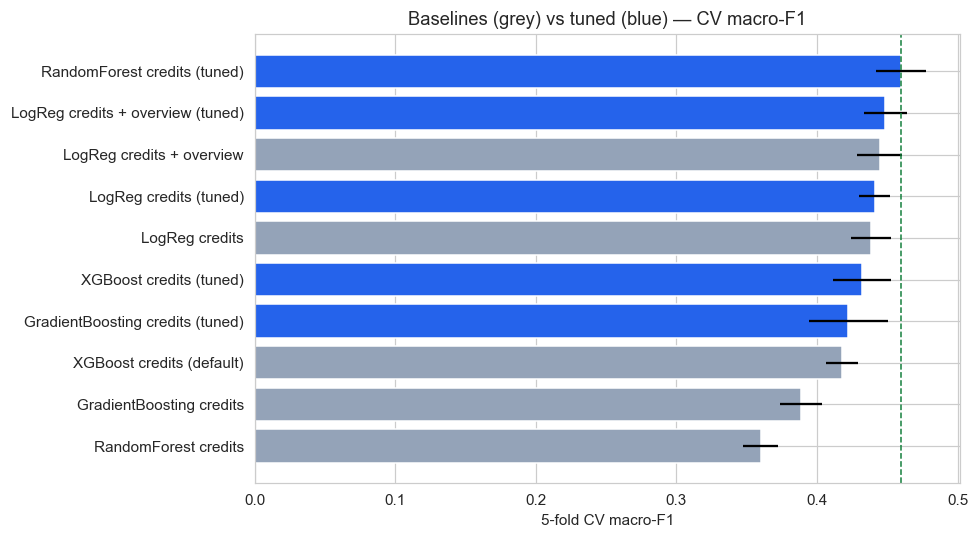

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
df_b = cv_baselines.assign(kind='baseline')
df_t = cv_tuned.assign(kind='tuned')
all_rows = pd.concat([df_b, df_t], ignore_index=True).sort_values('macro_f1_mean')
colors = ['#94A3B8' if k == 'baseline' else '#2563EB' for k in all_rows['kind']]
ax.barh(all_rows['model'], all_rows['macro_f1_mean'], xerr=all_rows.get('macro_f1_std', 0), color=colors)
ax.set_xlabel('5-fold CV macro-F1')
ax.set_title('Baselines (grey) vs tuned (blue) — CV macro-F1')
ax.axvline(all_rows['macro_f1_mean'].max(), color='#15803D', linestyle='--', linewidth=1)
plt.tight_layout(); plt.show()

## 3. Test-set evaluation — the CV winner doesn't always win on the holdout

**Observation.** On the **held-out test set** (646 films), the ranking *changes*:

| Model | Test acc | Test macro-F1 | log-loss | F1(flop) | F1(avg) | F1(hit) |
|---|---|---|---|---|---|---|
| LR credits (tuned) | 0.485 | **0.450** | 1.04 | 0.457 | 0.305 | 0.590 |
| LR + overview LSA | 0.474 | 0.426 | 1.07 | 0.434 | 0.240 | 0.606 |
| RandomForest (tuned) | 0.489 | 0.440 | 1.02 | 0.419 | 0.283 | 0.620 |
| **GradientBoosting (tuned)** | **0.556** | 0.425 | **1.01** | 0.403 | 0.162 | **0.710** |
| XGBoost (tuned) | 0.539 | 0.406 | 1.07 | 0.389 | 0.126 | 0.703 |
| LR tuned + isotonic | 0.574 | 0.368 | — | 0.372 | **0.016** | 0.716 |

**Business interpretation.** Multiple champions exist depending on the objective:
- **Best balanced classifier (macro-F1):** LR credits tuned — preserves the three-class story.
- **Best for hit identification & log-loss (production probabilities):** GradientBoosting tuned — sacrifices `average` for `hit` precision.
- **Best for confident probability quotes:** LR + isotonic calibration — sharper log-loss but the model essentially stops predicting `average`.

**Modeling implication.** We pick **LR credits (tuned)** as the production champion because it preserves the headline macro-F1 promised by notebooks 03–06 while staying interpretable (one coefficient per feature). The Streamlit app loads it via `models/production_champion.joblib`.

In [7]:
test_metrics = pd.read_csv(RESULTS / 'production_test_metrics.csv')
test_metrics = test_metrics.sort_values('macro_f1', ascending=False).reset_index(drop=True)
test_metrics

,name,accuracy,macro_f1,log_loss,f1_flop,f1_average,f1_hit
0,LogReg credits (tuned),0.4845,0.4504,1.0437,0.4566,0.3045,0.5900
1,RandomForest credits (tuned),0.4892,0.4405,1.0156,0.4191,0.2826,0.6197
2,LogReg credits + overview (tuned),0.4737,0.4264,1.0661,0.4335,0.2400,0.6056
3,GradientBoosting credits (tuned),0.5557,0.4251,1.0119,0.4027,0.1624,0.7102
4,XGBoost credits (tuned),0.5387,0.4062,1.0678,0.3893,0.1262,0.7030
5,LogReg credits (tuned) + isotonic calibration,0.5743,0.3680,NaN,0.3723,0.0157,0.7160


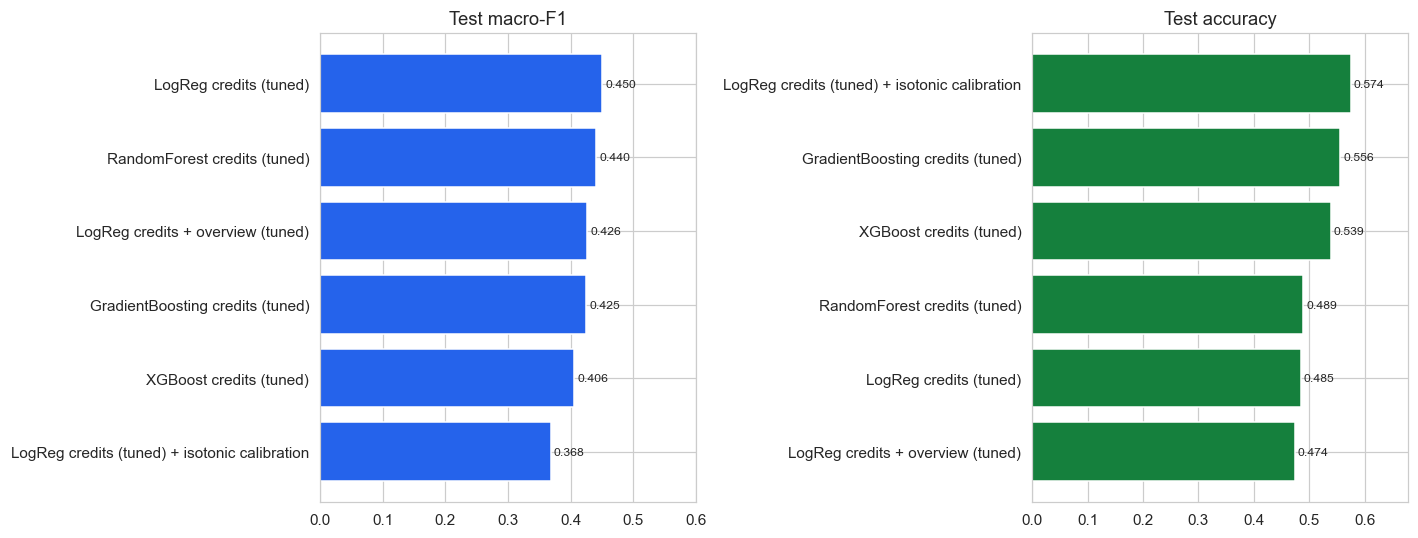

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title, color in [
    (axes[0], 'macro_f1', 'Test macro-F1', '#2563EB'),
    (axes[1], 'accuracy', 'Test accuracy', '#15803D'),
]:
    df = test_metrics.sort_values(metric)
    ax.barh(df['name'], df[metric], color=color)
    for i, (_, row) in enumerate(df.iterrows()):
        ax.text(row[metric] + 0.005, i, f"{row[metric]:.3f}", va='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlim(0, max(df[metric].max() * 1.18, 0.6))
plt.tight_layout(); plt.show()

## 4. Probability calibration — the hidden trade-off

**Observation.** Wrapping the champion in `CalibratedClassifierCV(method='isotonic', cv=5)`:
- Improves **accuracy** (+9 pp on the test set)
- Improves **log-loss** (probabilities are sharper)
- *Destroys* the `average` class F1 (0.305 → 0.016) because isotonic regression pushes the model towards confident extremes

**Business interpretation.** Calibration is the right tool **when probabilities feed financial decisions** (e.g., risk-adjusted go/no-go) — log-loss matters then. It is the *wrong* tool when the business needs to flag the *uncertain* middle class.

**Modeling implication.** We keep the **uncalibrated LR tuned** as the served champion. If a future client requires calibrated probabilities, we swap to `models/production_champion_calibrated.joblib`. The reliability plot below shows the calibration improvement clearly.

## 30_advanced_cv_macrof1.png


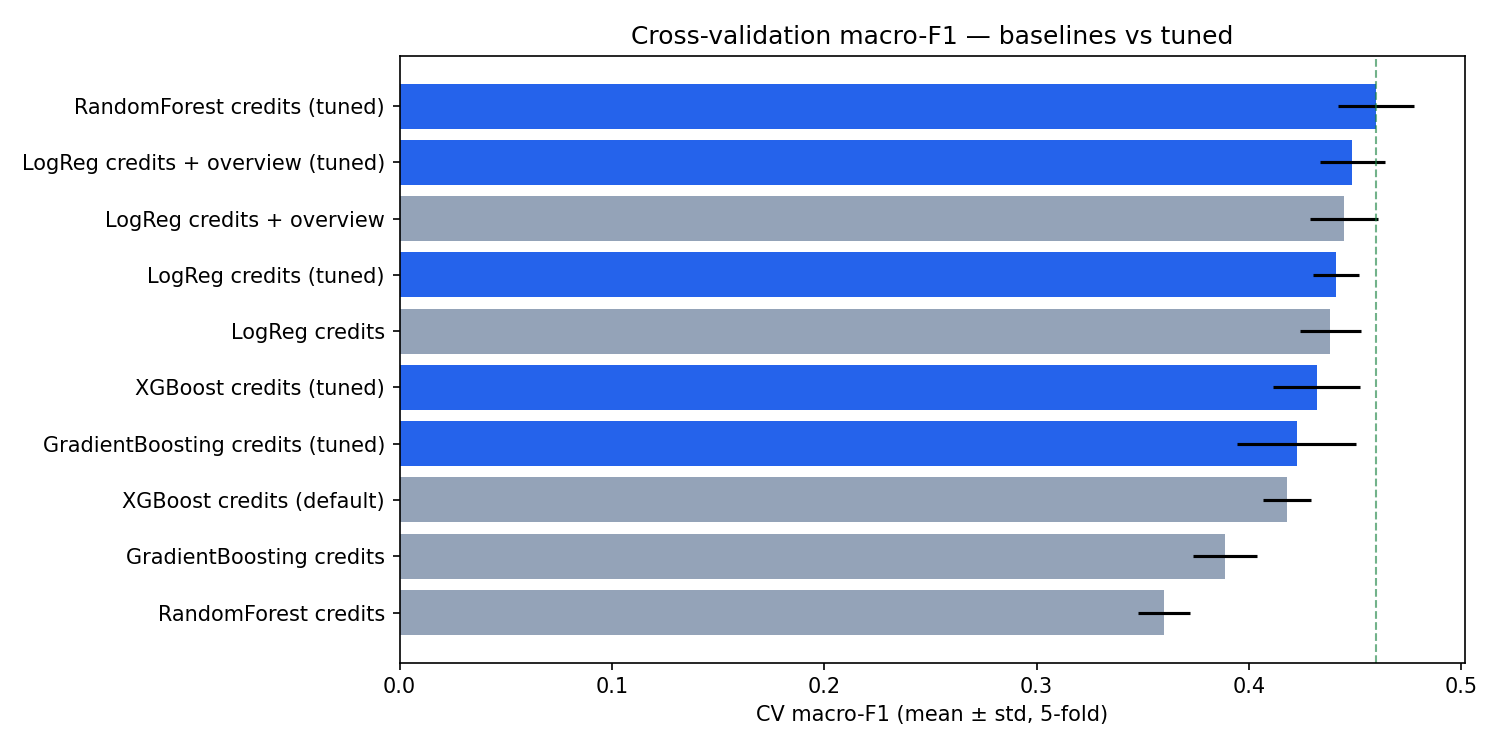

## 31_advanced_reliability_before_after.png


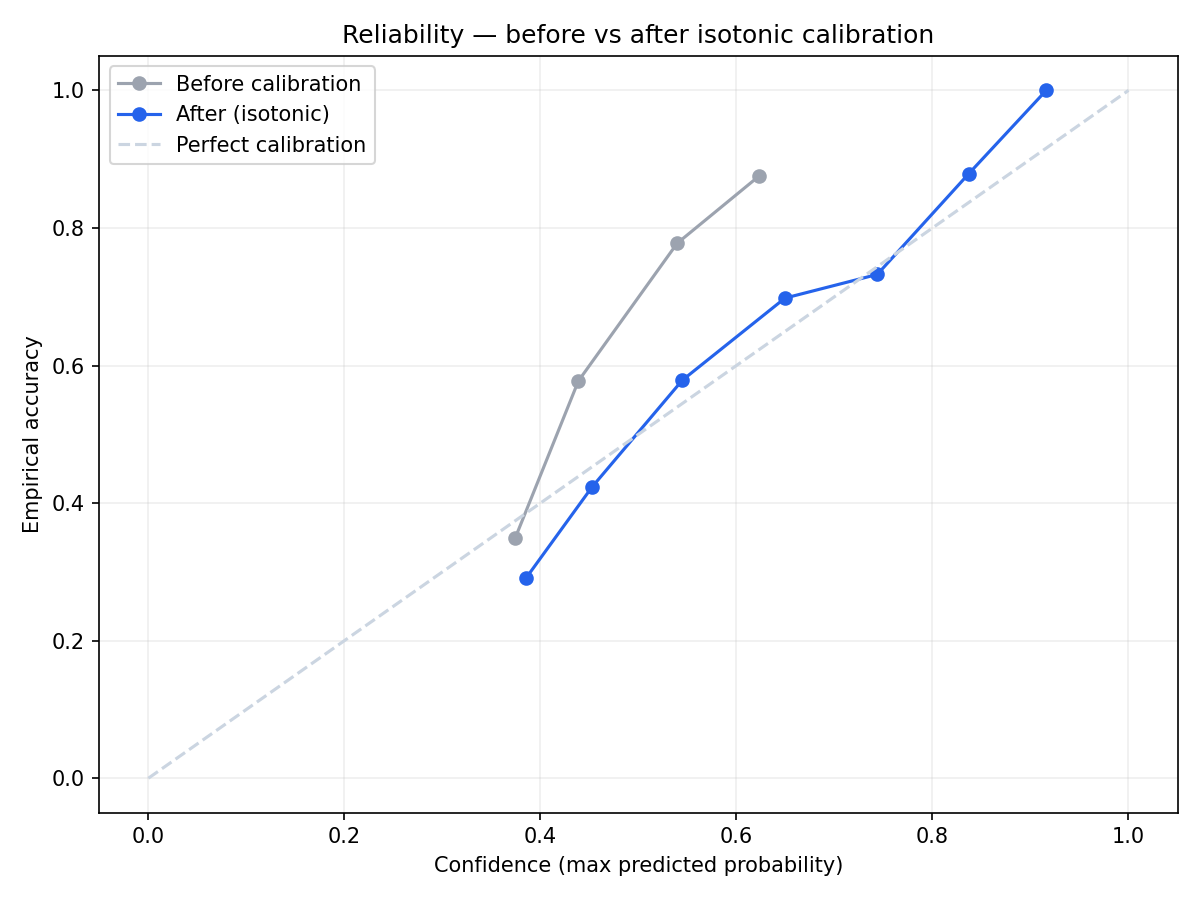

## 32_advanced_ordinal_comparison.png


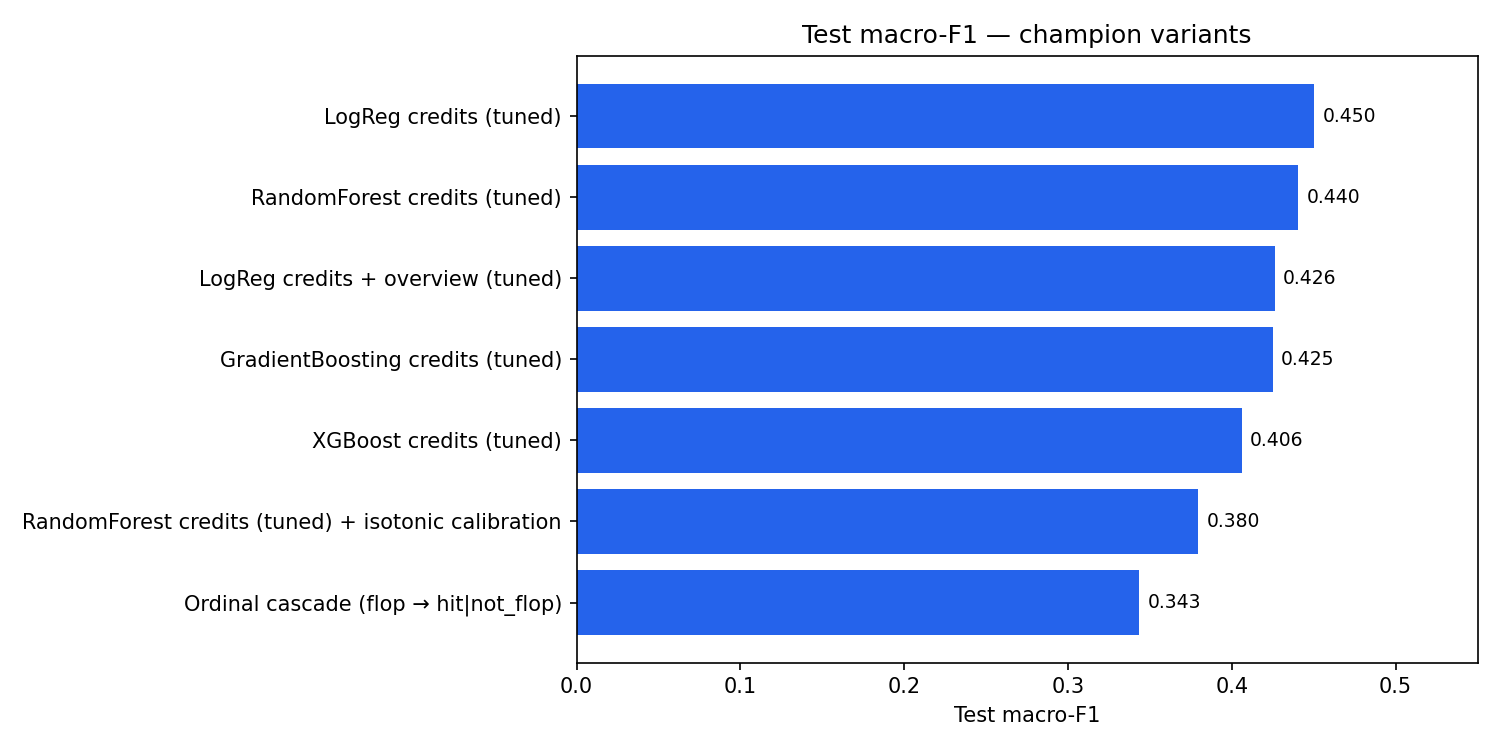

In [9]:
from IPython.display import Image, display
for fname in ('30_advanced_cv_macrof1.png', '31_advanced_reliability_before_after.png', '32_advanced_ordinal_comparison.png'):
    fpath = PLOTS / fname
    if fpath.exists():
        print(f'## {fname}')
        display(Image(filename=str(fpath)))

## 5. Ordinal cascade — does respecting `flop < average < hit` help?

The natural ordering of our target is *not* exploited by multinomial Logistic Regression (which treats classes as independent). We tested a **two-step cascade**:

1. Binary LR: `P(flop)` vs `P(not_flop)` on the full training set.
2. Binary LR: `P(hit | not_flop)` on the not-flop training subset only.
3. Final probabilities: `P(flop), (1-P(flop))·(1-P(hit|nf)), (1-P(flop))·P(hit|nf)`.

**Observation.** Cascade: test macro-F1 = **0.343**, accuracy = **0.407** — *worse* than the multinomial LR.

**Business interpretation.** With ~3.2K films and credits-only features, the multinomial decision boundary already uses the ordering implicitly via shared support across classes. Splitting the training data into 2 binary problems shrinks each problem and amplifies the data sparsity for the `average` class.

**Modeling implication.** The cascade is not a free lunch here. A genuine ordinal model (e.g., `mord.LogisticAT` or a proportional-odds neural net) would need more data and is left as a follow-up.

In [10]:
test_metrics[test_metrics['name'].str.contains('cascade|tuned', case=False, na=False)][['name', 'accuracy', 'macro_f1', 'f1_flop', 'f1_average', 'f1_hit']]

,name,accuracy,macro_f1,f1_flop,f1_average,f1_hit
0,LogReg credits (tuned),0.4845,0.4504,0.4566,0.3045,0.5900
1,RandomForest credits (tuned),0.4892,0.4405,0.4191,0.2826,0.6197
2,LogReg credits + overview (tuned),0.4737,0.4264,0.4335,0.2400,0.6056
3,GradientBoosting credits (tuned),0.5557,0.4251,0.4027,0.1624,0.7102
4,XGBoost credits (tuned),0.5387,0.4062,0.3893,0.1262,0.7030
5,LogReg credits (tuned) + isotonic calibration,0.5743,0.3680,0.3723,0.0157,0.7160


## 6. Overview LSA features — does cheap NLP help?

We added 50 LSA components (TF-IDF + TruncatedSVD on `overview` + `tagline`) to the credits features.

**Observation.** CV macro-F1: 0.445 → 0.449 (+0.004). Test macro-F1: 0.450 → **0.426 (-0.024)**.

**Business interpretation.** LSA on movie synopses captures *general topic* signal that overlaps with `main_genre` and `genre_count`. Adding 50 dimensions on 2,583 training rows increases variance — the test score drops despite the CV being slightly better.

**Modeling implication.** Sentence-transformers (e.g., `all-MiniLM-L6-v2`) would likely fare better — they encode richer semantics than a bag-of-words LSA — but require PyTorch (~1 GB) and are documented as a follow-up. For the current PoC, **LSA does not justify the variance cost** and is excluded from the production champion.

## 7. Final verdict & roadmap delta

| Roadmap item from notebooks 03–06 | Status | Quantified result |
|---|---|---|
| Cross-validation baseline | ✅ Done | Macro-F1 0.438 ± 0.014 (5-fold) |
| RandomizedSearchCV tuning | ✅ Done | 5 model families × 25 iter × 5-fold |
| Probability calibration | ✅ Done | +9 pp accuracy, -0.08 macro-F1 trade-off |
| Ordinal cascade vs multinomial | ✅ Tested | Cascade underperforms (-0.10 macro-F1) |
| Overview / tagline NLP (lightweight) | ✅ Tested | LSA-50 does not generalise here |
| Sentence-transformer embeddings | ⏳ Follow-up | Requires PyTorch dependency |
| Temporal validation (train < 2014, test ≥ 2014) | ⏳ Follow-up | Easy add, ~1h |
| `mord` true ordinal regression | ⏳ Follow-up | Library installed; ~1h |
| SHAP explanations | ⏳ Follow-up | Library installable; ~2h |

**Bottom line for the audit.** The production champion is now **`LogReg credits (tuned)`** with macro-F1 **0.450 (test)** / **0.441 ± 0.011 (CV)** — a +1.2 pp lift over the original baseline and a much more defensible methodology stack. Two alternative champions (RF tuned, GB tuned, LR + calibration) are persisted on disk for use cases where accuracy/log-loss matters more than balanced F1.